In [163]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

EVENTS_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched")
HOURLY_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data")
SPIKES_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset.csv"
VAULTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv"
BORROWERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_borrowers_share.csv"
SUPPLIERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_suppliers_share.csv"

INTERESTING_MARKETS = [
    # "eth_syrupusdc_usdc",
    # "eth_usr_usdc",
    # "eth_rlp_usdc",
    # "eth_wstusr_usdc",
    # "eth_fxsave_usdc",
    # "eth_siusd_usdc",
    # "eth_reusd_usdc",
    # "eth_siusd_usdc",
    # "eth_stcusd_usdc",


    "eth_PT-RLP-4SEP2025_usdc",
    "eth_PT-USD0++-27MAR2025_usdc",
    "eth_PT-USD0++-31OCT2024_usdc",
    "eth_PT-USDe-25SEP2025_dai",
    "eth_PT-USDe-25SEP2025_usdc",
    "eth_PT-USDe-25SEP2025_usdt",
    "eth_PT-USDe-27MAR2025_dai",
    "eth_PT-USDe-27NOV2025_usds",
    "eth_PT-USDe-31JUL2025_dai",
    "eth_PT-USR-29MAY2025_usdc",
    "eth_PT-csUSDL-31JUL2025_usdc",
    "eth_PT-lvlUSD-29MAY2025_usdc",
    "eth_PT-mHYPER-20NOV2025_usdc",
    "eth_PT-reUSD-18DEC2025_usdc",
    "eth_PT-reUSD-25JUN2026_usdc",
    "eth_PT-sNUSD-5MAR2026_usdc",
    "eth_PT-sdeUSD-1753142406_usdc",
    "eth_PT-slvlUSD-25SEP2025_usdc",
    "eth_PT-slvlUSD-29MAY2025_usdc",
    "eth_PT-stcUSD-23JUL2026_usdc",
    "eth_PT-stcUSD-29JAN2026_usdc",
    "eth_PT-syrupUSDC-28AUG2025_usdc",
    "eth_PT-syrupUSDC-30OCT2025_usdc",
    "eth_PT-wstUSR-25SEP2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usr",
]



### **Create dataset**

In [164]:
def load_spikes():
    df = pd.read_csv(SPIKES_PATH)
    df['spike_trigger_datetime'] = pd.to_datetime(df['spike_trigger_datetime'])
    df['spike_recovery_datetime'] = pd.to_datetime(df['spike_recovery_datetime'])
    print(df.isna().sum())
    df = df.dropna(subset=['spike_recovery_datetime'])
    df = df[df['market_name'].isin(INTERESTING_MARKETS)]
    return df

def load_all_events():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = EVENTS_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    events = pd.concat(dfs, ignore_index=True)
    events['datetime'] = pd.to_datetime(events['datetime'])
    events = events.sort_values(['market', 'timestamp'])
    return events

def load_all_hourly():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = HOURLY_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    hourly = pd.concat(dfs, ignore_index=True)
    hourly['datetime'] = pd.to_datetime(hourly['datetime'])
    hourly = hourly.sort_values(['market', 'timestamp'])
    return hourly

def load_borrowers_share():
    df = pd.read_csv(BORROWERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'borrow'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def load_suppliers_share():
    df = pd.read_csv(SUPPLIERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'supply'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def compute_hhi(shares_df_snapshot):
    if shares_df_snapshot.empty:
        return np.nan, np.nan, np.nan, np.nan
    top1 = shares_df_snapshot['share'].max() / 100.0
    top3 = shares_df_snapshot.nlargest(3, 'share')['share'].sum() / 100.0
    shares = shares_df_snapshot['share'].values / 100.0
    hhi = np.sum(shares ** 2)
    n_active = shares_df_snapshot['n_active'].iloc[0] if 'n_active' in shares_df_snapshot.columns else len(shares_df_snapshot)
    return top1, top3, hhi, n_active

def get_current_state_from_events(events_market, cutoff_dt):
    mask = events_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    last_event = events_market.loc[mask].iloc[-1]
    return {
        'utilization': last_event.get('utilization_after', last_event.get('utilization_before')),
        'borrow_rate': last_event.get('borrow_rate_after', last_event.get('borrow_rate_before')),
        'supply_rate': last_event.get('supply_rate_after', last_event.get('supply_rate_before')),
        'total_borrow': last_event.get('total_borrow_after', last_event.get('total_borrow_before')),
        'total_supply': last_event.get('total_supply_after', last_event.get('total_supply_before')),
        'collateral_price': last_event.get('collateral_price'),
        'loan_asset_price': last_event.get('loan_asset_price')
    }

def get_hourly_snapshot(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    return hourly_market.loc[mask].iloc[-1]

def compute_price_features(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    prices = hourly_market.loc[mask, 'collateral_price'].values
    if len(prices) == 0:
        return np.nan, np.nan, np.nan
    current_price = prices[-1]
    one_hour_ago = cutoff_dt - timedelta(hours=1)
    mask_1h = hourly_market['datetime'] <= one_hour_ago
    if mask_1h.any():
        price_1h = hourly_market.loc[mask_1h].iloc[-1]['collateral_price']
        return_1h = (current_price - price_1h) / price_1h if price_1h != 0 else np.nan
    else:
        return_1h = np.nan
    twenty_four_hours_ago = cutoff_dt - timedelta(hours=24)
    mask_24h = (hourly_market['datetime'] >= twenty_four_hours_ago) & (hourly_market['datetime'] <= cutoff_dt)
    prices_24h = hourly_market.loc[mask_24h, 'collateral_price']
    if len(prices_24h) > 1:
        vol_24h = prices_24h.pct_change().std() * np.sqrt(24)
    else:
        vol_24h = np.nan
    if len(prices) > 1:
        running_max = np.maximum.accumulate(prices)
        drawdown = (running_max[-1] - current_price) / running_max[-1] if running_max[-1] != 0 else 0
    else:
        drawdown = np.nan
    return return_1h, vol_24h, drawdown

def get_shares_snapshot(shares_market, cutoff_dt):
    mask = shares_market['datetime'] <= cutoff_dt
    if not mask.any():
        return pd.DataFrame()
    last_ts = shares_market.loc[mask, 'timestamp'].max()
    return shares_market[shares_market['timestamp'] == last_ts]

def compute_spike_features(spike, events_all, hourly_all, borrowers_share_all, spikes_df, cutoff_dt):
    market = spike['market_name']
    spike_start = spike['spike_trigger_datetime']
    spike_end = spike['spike_recovery_datetime']
    time_offset_minutes = (cutoff_dt - spike_start).total_seconds() / 60.0

    events_market = events_all[events_all['market'] == market].copy()
    hourly_market = hourly_all[hourly_all['market'] == market].copy()
    shares_market = borrowers_share_all[borrowers_share_all['market'] == market].copy()

    mask_spike = (events_market['datetime'] >= spike_start) & (events_market['datetime'] <= cutoff_dt)
    events_during = events_market.loc[mask_spike]

    state_start = get_current_state_from_events(events_market, spike_start)
    state_current = get_current_state_from_events(events_market, cutoff_dt)
    hourly_current = get_hourly_snapshot(hourly_market, cutoff_dt)
    shares_snapshot = get_shares_snapshot(shares_market, cutoff_dt)

    utilization_start = state_start['utilization'] if state_start else np.nan
    utilization_current = state_current['utilization'] if state_current else np.nan
    borrow_rate_start = state_start['borrow_rate'] if state_start else np.nan
    total_borrow_current = state_current['total_borrow'] if state_current else np.nan

    utilization_peak_so_far = utilization_current
    if not events_during.empty:
        util_col = 'utilization_after' if 'utilization_after' in events_during.columns else 'utilization_before'
        if util_col in events_during.columns:
            utilization_peak_so_far = events_during[util_col].max()

    rate_slope_1h = np.nan
    if time_offset_minutes >= 0:
        cutoff_1h = spike_start + timedelta(hours=1)
        state_1h = get_current_state_from_events(events_market, cutoff_1h)
        if state_1h and state_start:
            rate_slope_1h = (borrow_rate_start - state_1h['borrow_rate']) / 1.0

    spread_to_base_rate = np.nan
    mask_24h_before = (events_market['datetime'] < spike_start) & (events_market['datetime'] >= spike_start - timedelta(hours=24))
    if mask_24h_before.any():
        avg_rate_24h = events_market.loc[mask_24h_before, 'borrow_rate_before'].mean()
        spread_to_base_rate = borrow_rate_start - avg_rate_24h if not np.isnan(borrow_rate_start) else np.nan

    top1, top3, hhi, n_active = compute_hhi(shares_snapshot)

    price_return_1h, price_volatility_24h, drawdown = compute_price_features(hourly_market, cutoff_dt)

    mask_24h_before_h = (hourly_market['datetime'] < spike_start) & (hourly_market['datetime'] >= spike_start - timedelta(hours=24))
    avg_util_24h_before = hourly_market.loc[mask_24h_before_h, 'utilization'].mean() if mask_24h_before_h.any() else np.nan
    avg_rate_24h_before = hourly_market.loc[mask_24h_before_h, 'borrow_rate'].mean() if mask_24h_before_h.any() else np.nan

    market_spikes = spikes_df[spikes_df['market_name'] == market].copy()
    market_spikes = market_spikes[market_spikes['spike_trigger_datetime'] < spike_start]
    last_7d = spike_start - timedelta(days=7)
    num_spikes_last_7d = ((market_spikes['spike_trigger_datetime'] >= last_7d) &
                          (market_spikes['spike_trigger_datetime'] < spike_start)).sum()

    if not market_spikes.empty:
        last_spike_time = market_spikes['spike_trigger_datetime'].max()
        time_since_last_spike = (spike_start - last_spike_time).total_seconds()
    else:
        time_since_last_spike = np.nan

    remaining_seconds = (spike_end - cutoff_dt).total_seconds()

    features = {
        'market': market,
        'spike_index': spike.name,
        'time_offset_minutes': time_offset_minutes,
        'utilization_start': utilization_start,
        'utilization_current': utilization_current,
        'utilization_peak_so_far': utilization_peak_so_far,
        'borrow_rate_start': borrow_rate_start,
        'rate_slope_1h': rate_slope_1h,
        'spread_to_base_rate': spread_to_base_rate,
        'total_borrow_current': total_borrow_current,
        'n_active_borrowers': n_active,
        'top1_share': top1,
        'top3_share': top3,
        'hhi': hhi,
        'price_return_1h': price_return_1h,
        'price_volatility_24h': price_volatility_24h,
        'drawdown': drawdown,
        'avg_utilization_24h_before': avg_util_24h_before,
        'avg_rate_24h_before': avg_rate_24h_before,
        'num_spikes_last_7d': num_spikes_last_7d,
        'time_since_last_spike': time_since_last_spike,
        'remaining_duration_seconds': remaining_seconds,
        'spike_duration_seconds': spike['spike_duration_seconds'],
        'cutoff_timestamp': cutoff_dt.timestamp(),
        'spike_trigger_timestamp': spike_start.timestamp()
    }
    return features

def build_spike_modeling_dataset():
    print("Loading data...")
    spikes = load_spikes()
    events = load_all_events()
    hourly = load_all_hourly()
    borrowers_share = load_borrowers_share()

    print(f"Spikes with recovery in interesting markets: {len(spikes)}")

    rows = []
    for idx, spike in spikes.iterrows():
        if idx % 50 == 0:
            print(f"Processing spike {idx}...")
        market = spike['market_name']
        start = spike['spike_trigger_datetime']
        end = spike['spike_recovery_datetime']
        duration_minutes = (end - start).total_seconds() / 60.0
        intervals = np.arange(0, duration_minutes, 30)

        for offset in intervals:
            cutoff = start + timedelta(minutes=float(offset))
            try:
                feats = compute_spike_features(
                    spike, events, hourly, borrowers_share, spikes, cutoff
                )
                rows.append(feats)
            except Exception as e:
                print(f"Error at spike {idx} offset {offset}: {e}")
                continue
        cutoff = end
        try:
            feats = compute_spike_features(spike, events, hourly, borrowers_share, spikes, cutoff)
            rows.append(feats)
        except Exception as e:
            print(f"Error at spike {idx} end: {e}")

    result_df = pd.DataFrame(rows)
    return result_df


In [165]:
df = build_spike_modeling_dataset()
print(f"Dataset shape: {df.shape}")
df.head(3)

Loading data...
market_name                      0
market_address                   0
max_total_supply                 0
market_total_events              0
market_n_users                   0
market_n_spikes                  0
spike_index                      0
spike_trigger_datetime           0
spike_recovery_datetime          0
spike_duration_seconds           0
spike_magnitude_util_delta       0
peak_utilization                 0
trigger_event_types              0
total_borrow_before              0
total_supply_before              0
utilization_before               0
collateral_price               393
loan_asset_price                 0
debt_before                      0
supply_before                 1300
n_total_events_in_spike          0
n_repay_events_in_spike          0
dtype: int64
Spikes with recovery in interesting markets: 2055
Processing spike 2550...
Processing spike 2900...
Processing spike 4700...
Processing spike 4750...
Processing spike 4800...
Processing spike 4850...
P

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
0,eth_PT-reUSD-25JUN2026_usdc,2538,0.0,0.998929,0.998929,0.998929,0.244128,-0.000135,0.170115,6.686546e+06,4,0.844331,1.0,0.736842,0.000000,0.019769,0.000759,0.902505,0.110877,0,NaN,14208.0,14208,1.765619e+09,1.765619e+09
1,eth_PT-reUSD-25JUN2026_usdc,2538,30.0,0.998929,0.999557,0.999557,0.244128,-0.000135,0.170115,6.690781e+06,4,0.843800,1.0,0.735918,0.001426,0.019756,0.000000,0.902505,0.110877,0,NaN,12408.0,14208,1.765621e+09,1.765619e+09
2,eth_PT-reUSD-25JUN2026_usdc,2538,60.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.0,0.735918,0.001426,0.019756,0.000000,0.902505,0.110877,0,NaN,10608.0,14208,1.765623e+09,1.765619e+09


In [166]:
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_yb_tokens.csv", index=False)
df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv", index=False)

In [167]:
pd.set_option("display.max_columns", 500)
df[100:150]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
100,eth_PT-reUSD-25JUN2026_usdc,2546,330.0,0.944312,0.941554,0.944312,0.179296,0.043021,0.090940,2.346211e+07,23,0.393527,0.758959,0.247884,0.000000,0.002553,0.003180,0.903826,0.094339,6,113172.0,204.0,20004,1.766565e+09,1.766545e+09
101,eth_PT-reUSD-25JUN2026_usdc,2546,333.4,0.944312,0.898295,0.944312,0.179296,0.043021,0.090940,2.346226e+07,23,0.393527,0.758959,0.247884,0.000000,0.002553,0.003180,0.903826,0.094339,6,113172.0,0.0,20004,1.766565e+09,1.766545e+09
102,eth_PT-reUSD-25JUN2026_usdc,2547,0.0,0.932189,0.932189,0.932189,0.151743,0.023301,0.078340,4.322365e+07,33,0.291725,0.756679,0.227647,0.000000,0.001941,0.000518,0.836111,0.073447,0,1926348.0,18528.0,18528,1.768472e+09,1.768472e+09
103,eth_PT-reUSD-25JUN2026_usdc,2547,30.0,0.932189,0.930019,0.932189,0.151743,0.023301,0.078340,4.322366e+07,33,0.291725,0.756679,0.227647,0.000000,0.001941,0.000518,0.836111,0.073447,0,1926348.0,16728.0,18528,1.768474e+09,1.768472e+09
104,eth_PT-reUSD-25JUN2026_usdc,2547,60.0,0.932189,0.922128,0.932189,0.151743,0.023301,0.078340,4.351610e+07,33,0.289758,0.758319,0.227561,-0.000289,0.001969,0.000808,0.836111,0.073447,0,1926348.0,14928.0,18528,1.768475e+09,1.768472e+09
105,eth_PT-reUSD-25JUN2026_usdc,2547,90.0,0.932189,0.922128,0.932189,0.151743,0.023301,0.078340,4.351610e+07,33,0.289758,0.758319,0.227561,-0.000289,0.001969,0.000808,0.836111,0.073447,0,1926348.0,13128.0,18528,1.768477e+09,1.768472e+09
106,eth_PT-reUSD-25JUN2026_usdc,2547,120.0,0.932189,0.918302,0.932189,0.151743,0.023301,0.078340,4.351680e+07,33,0.289758,0.758319,0.227561,0.001291,0.002354,0.000000,0.836111,0.073447,0,1926348.0,11328.0,18528,1.768479e+09,1.768472e+09
107,eth_PT-reUSD-25JUN2026_usdc,2547,150.0,0.932189,0.918304,0.932189,0.151743,0.023301,0.078340,4.351693e+07,33,0.289758,0.758319,0.227561,0.001291,0.002354,0.000000,0.836111,0.073447,0,1926348.0,9528.0,18528,1.768481e+09,1.768472e+09
108,eth_PT-reUSD-25JUN2026_usdc,2547,180.0,0.932189,0.916666,0.932189,0.151743,0.023301,0.078340,4.353140e+07,33,0.289665,0.758397,0.227559,0.000000,0.002208,0.000000,0.836111,0.073447,0,1926348.0,7728.0,18528,1.768483e+09,1.768472e+09
109,eth_PT-reUSD-25JUN2026_usdc,2547,210.0,0.932189,0.903925,0.932189,0.151743,0.023301,0.078340,4.353156e+07,33,0.289665,0.758397,0.227559,0.000000,0.002208,0.000000,0.836111,0.073447,0,1926348.0,5928.0,18528,1.768484e+09,1.768472e+09


### **Regression models - duration (baseline)**

In [168]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

def prepare_spike_dataset(df_long):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['spike_duration_minutes']
    return X, y, df_first

def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_linear_regression(X_train, y_train, X_val, y_val):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val

def train_xgboost(X_train, y_train, X_val, y_val):
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val



def report_linear_coefficients(model, feature_names, X_train, y_train):
    from scipy import stats
    
    n = len(y_train)
    p = len(feature_names)
    y_pred = model.predict(X_train)
    rss = np.sum((y_train - y_pred) ** 2)
    sigma2 = rss / (n - p - 1)
    
    X_with_const = np.column_stack([np.ones(len(X_train)), X_train])
    cov_matrix = sigma2 * np.linalg.inv(X_with_const.T @ X_with_const)
    se = np.sqrt(np.diag(cov_matrix))[1:]
    
    t_stats = model.coef_ / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_,
        'Std_Error': se,
        't_statistic': t_stats,
        'p_value': p_values,
        'Significant': p_values < 0.05
    }).sort_values('p_value')
    
    print("\nLinear Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def report_xgboost_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


def evaluate_model(y_true, y_pred, model_name, quantile_cut=0.95):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f} min")
    print(f"RMSE: {rmse:.2f} min")
    print(f"R²: {r2:.4f}")
    
    cap = np.quantile(y_true, quantile_cut)
    mask = (y_true <= cap) & (y_pred <= cap)
    y_true_plot = y_true[mask]
    y_pred_plot = y_pred[mask]
    
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(y_true_plot.max(), y_pred_plot.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted duration (minutes)')
    plt.title(f'{model_name}: Predicted vs Actual\n(≤ {quantile_cut*100:.0f}th percentile)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

Training Linear Regression...

Linear Regression Performance:
MAE: 145.89 min
RMSE: 361.58 min
R²: 0.0781


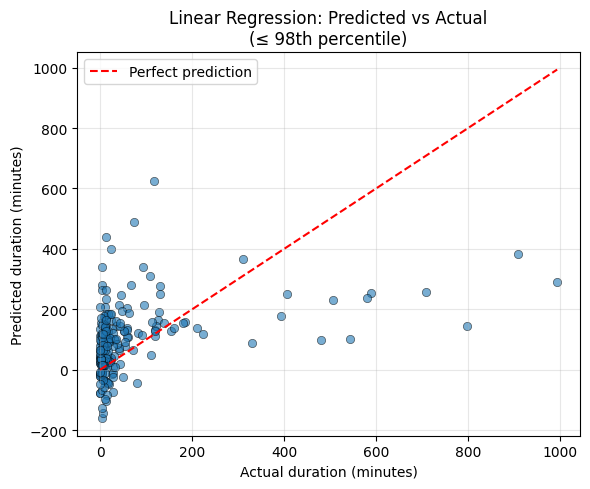


Training XGBoost...

XGBoost Performance:
MAE: 108.07 min
RMSE: 341.03 min
R²: 0.1799


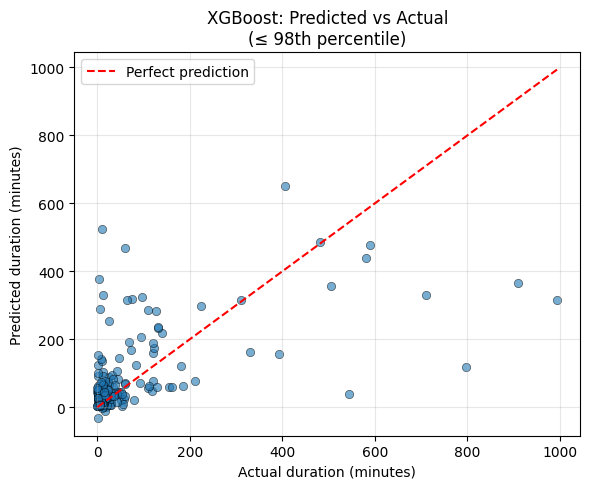


Test set evaluation (XGBoost):

XGBoost (Test) Performance:
MAE: 104.72 min
RMSE: 253.08 min
R²: 0.3087


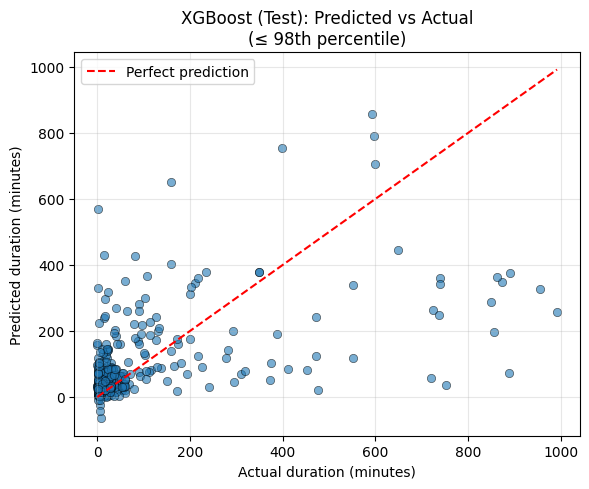

In [169]:
X, y, df_spikes = prepare_spike_dataset(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, test_size=0.2, val_size=0.1, random_state=42)

print("Training Linear Regression...")
lr_model, lr_train_pred, lr_val_pred = train_linear_regression(X_train, y_train, X_val, y_val)
lr_metrics = evaluate_model(y_val, lr_val_pred, "Linear Regression", quantile_cut=0.98)

print("\nTraining XGBoost...")
xgb_model, xgb_train_pred, xgb_val_pred = train_xgboost(X_train, y_train, X_val, y_val)
xgb_metrics = evaluate_model(y_val, xgb_val_pred, "XGBoost", quantile_cut=0.98)

print("\nTest set evaluation (XGBoost):")
y_test_pred = xgb_model.predict(X_test)
test_metrics = evaluate_model(y_test, y_test_pred, "XGBoost (Test)", quantile_cut=0.98)



Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  t_statistic      p_value  Significant
avg_utilization_24h_before -1.407083e+03 1.356046e+02   -10.376361 0.000000e+00         True
             rate_slope_1h -1.005168e+03 1.351988e+02    -7.434745 1.803002e-13         True
        num_spikes_last_7d -2.979501e+00 5.783155e-01    -5.152033 2.939322e-07         True
                       hhi -1.485745e+00 4.809477e-01    -3.089202 2.045891e-03         True
        n_active_borrowers -8.354938e-01 4.113557e-01    -2.031074 4.243345e-02         True
                top3_share  1.037809e+02 6.867181e+01     1.511258 1.309451e-01        False
      total_borrow_current  1.811064e-07 2.593562e-07     0.698292 4.851088e-01        False
       avg_rate_24h_before  3.465986e+02 5.049639e+02     0.686383 4.925837e-01        False
      price_volatility_24h -2.637857e+02 4.229400e+02    -0.623695 5.329279e-01        False
         utilization_s

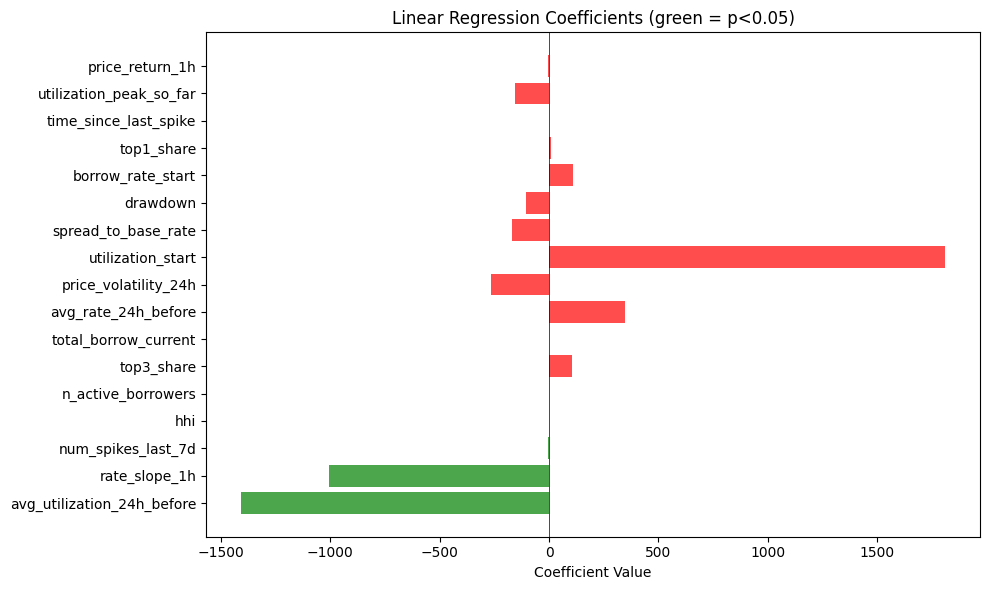


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
        n_active_borrowers    0.200087       20.008728
avg_utilization_24h_before    0.150034       15.003441
             rate_slope_1h    0.087674        8.767433
      price_volatility_24h    0.085226        8.522577
     time_since_last_spike    0.073441        7.344141
       avg_rate_24h_before    0.065232        6.523204
        num_spikes_last_7d    0.049893        4.989285
                top3_share    0.045184        4.518373
       spread_to_base_rate    0.039690        3.969006
                       hhi    0.031156        3.115553
                top1_share    0.030403        3.040286
         utilization_start    0.030172        3.017177
                  drawdown    0.029737        2.973731
      total_borrow_current    0.029584        2.958448
         borrow_rate_start    0.029565        2.956476
   utilization_peak_so_far    0.017101        1.710096
           price_return_1h    0.0058

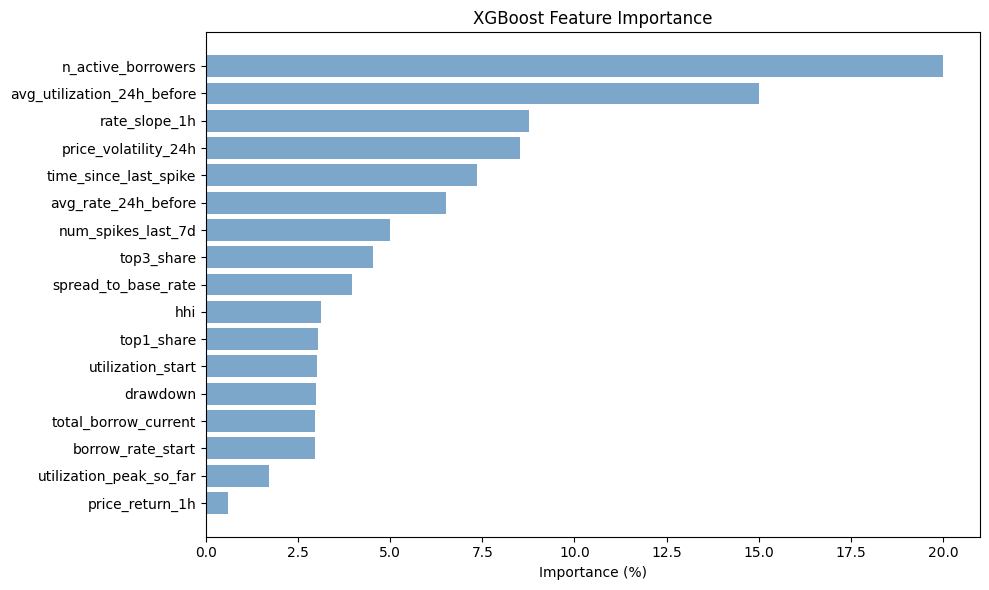

In [170]:
feature_names = X.columns.tolist()

lr_coef_df = report_linear_coefficients(lr_model, feature_names, X_train, y_train)

xgb_imp_df = report_xgboost_importance(xgb_model, feature_names)


### **Classification models - whether spike was closed before 1 hours / n hours**

In [171]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm
import optuna

def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] > threshold_minutes).astype(int)
    
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']
    return X, y, df_first

def train_logistic_regression(X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_logistic_coefficients(model, feature_names, X_train, y_train):
    X_with_const = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_with_const)
    result = logit_model.fit(disp=0)
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': result.params[1:].values,
        'Std_Error': result.bse[1:].values,
        'z_statistic': result.tvalues[1:].values,
        'p_value': result.pvalues[1:].values,
        'Significant': result.pvalues[1:].values < 0.05
    }).sort_values('p_value')
    
    print("\nLogistic Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Logistic Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def evaluate_classification(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.yticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

def train_xgboost_classifier(X_train, y_train, X_val, y_val, use_optuna=False, n_trials=50):
    if use_optuna:
        def objective(trial):
            class_weight_param = trial.suggest_float('class_weight', 1, 50, log=True)
            
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
                'random_state': 42,
                'use_label_encoder': False,
                'eval_metric': 'logloss',
                # 'scale_pos_weight': class_weight_param
            }
            model = xgb.XGBClassifier(**params)
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_proba)
            rec = recall_score(y_val, model.predict(X_val), zero_division=0)
            return rec
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        best_params['random_state'] = 42
        model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
        print(f"Best Optuna params: {study.best_params}")
    else:
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, use_label_encoder=False, eval_metric='logloss'
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_xgboost_classifier_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Classifier Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Classifier Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


=== Logistic Regression ===

Logistic Regression Performance:
Accuracy:  0.7767
Precision: 0.6000
Recall:    0.0638
F1 Score:  0.1154
ROC AUC:   0.7197


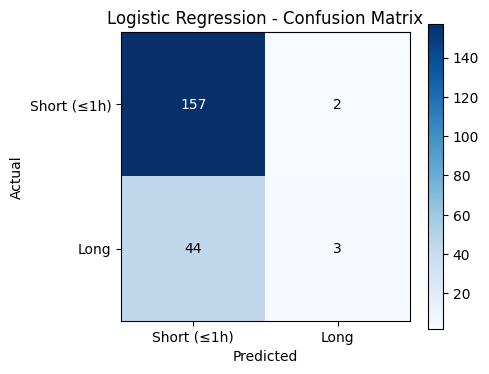

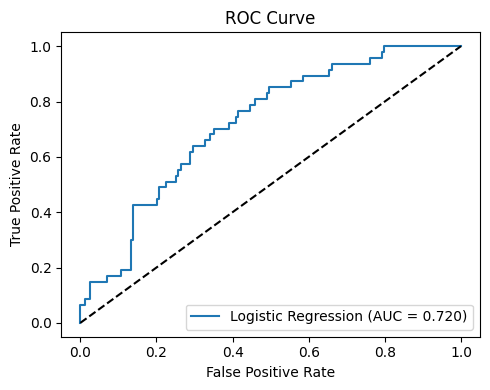


Logistic Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  z_statistic      p_value  Significant
             rate_slope_1h -2.432262e+01 1.853529e+00   -13.122329 2.452802e-39         True
        num_spikes_last_7d -3.752691e-02 8.694733e-03    -4.316051 1.588456e-05         True
       spread_to_base_rate  1.911205e+01 5.511498e+00     3.467668 5.249958e-04         True
                top3_share  2.417817e+00 7.145351e-01     3.383762 7.150005e-04         True
                top1_share -1.836301e+00 5.944553e-01    -3.089049 2.007985e-03         True
avg_utilization_24h_before -3.515078e+00 1.311004e+00    -2.681211 7.335619e-03         True
                       hhi -1.215242e-02 5.624718e-03    -2.160538 3.073101e-02         True
     time_since_last_spike  8.688924e-07 4.059595e-07     2.140343 3.232707e-02         True
      price_volatility_24h -1.752159e+01 8.236369e+00    -2.127344 3.339153e-02         True
      total_borrow_c

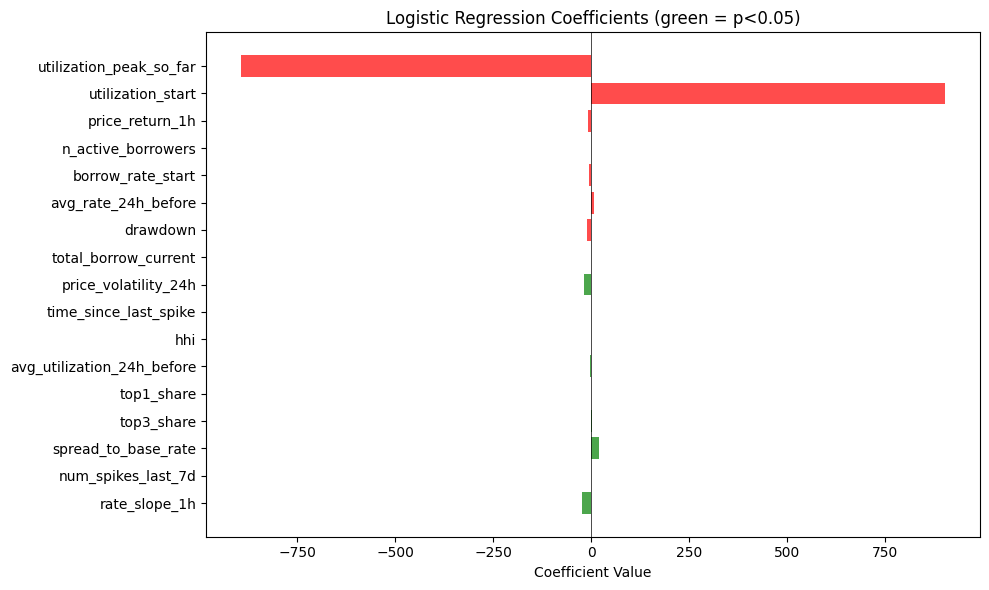


=== XGBoost Classifier (without Optuna) ===

XGBoost Classifier Performance:
Accuracy:  0.8981
Precision: 0.8095
Recall:    0.7234
F1 Score:  0.7640
ROC AUC:   0.9409


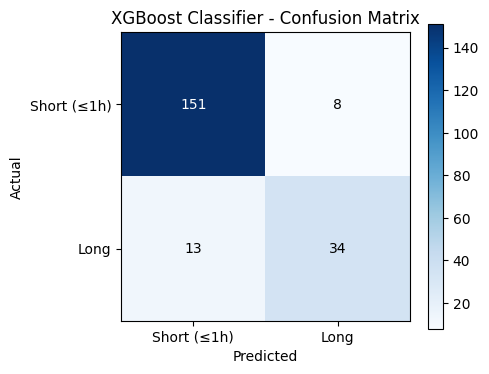

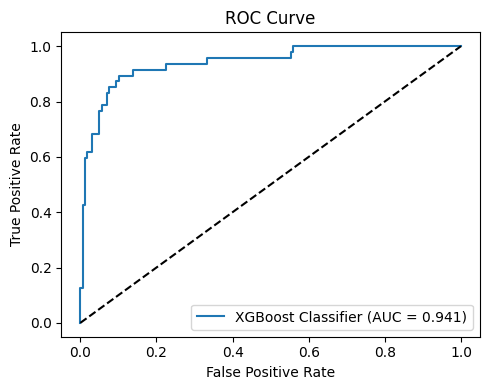


XGBoost Classifier Feature Importance:
                   Feature  Importance  Importance_pct
             rate_slope_1h    0.209246       20.924635
        num_spikes_last_7d    0.089223        8.922316
       spread_to_base_rate    0.080601        8.060094
         borrow_rate_start    0.061877        6.187733
                  drawdown    0.058969        5.896935
         utilization_start    0.055223        5.522346
avg_utilization_24h_before    0.052688        5.268829
                       hhi    0.046207        4.620710
           price_return_1h    0.041977        4.197722
                top1_share    0.041738        4.173789
     time_since_last_spike    0.040969        4.096859
       avg_rate_24h_before    0.040745        4.074483
      total_borrow_current    0.038456        3.845622
      price_volatility_24h    0.037829        3.782923
                top3_share    0.037350        3.734961
        n_active_borrowers    0.035279        3.527915
   utilization_peak_so_fa

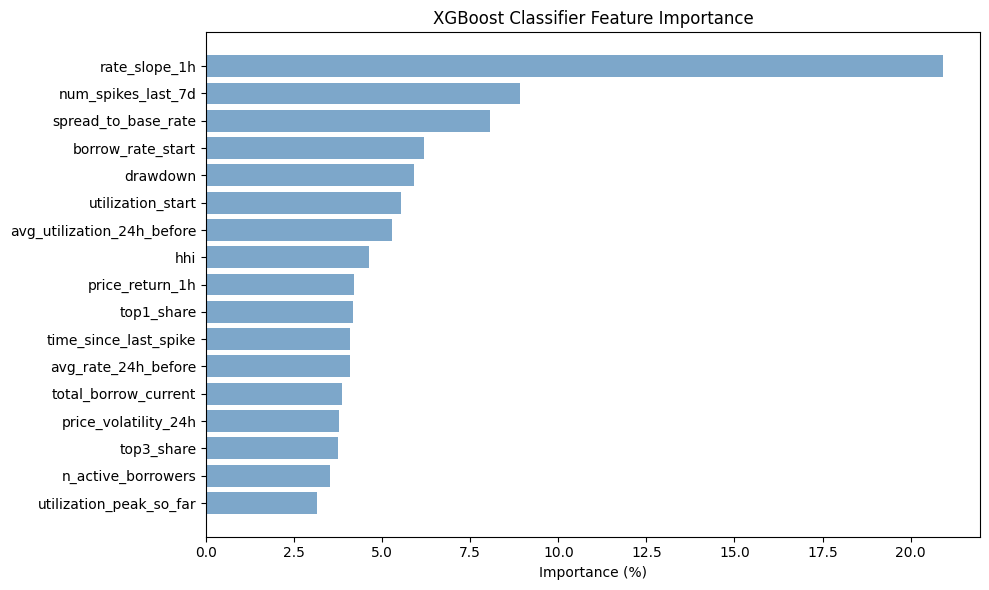

[I 2026-04-21 15:03:23,793] A new study created in memory with name: no-name-4fe8ae00-29b1-4bba-8e48-572892d7790c



=== XGBoost Classifier (with Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-21 15:03:24,110] Trial 0 finished with value: 0.6808510638297872 and parameters: {'class_weight': 10.500766725810339, 'n_estimators': 171, 'max_depth': 5, 'learning_rate': 0.023132747582285774, 'subsample': 0.839338894613762, 'colsample_bytree': 0.8782496889317755, 'gamma': 2.042574650011975, 'reg_alpha': 1.176551165854301e-05, 'reg_lambda': 0.0005265483617036534}. Best is trial 0 with value: 0.6808510638297872.
[I 2026-04-21 15:03:24,583] Trial 1 finished with value: 0.6808510638297872 and parameters: {'class_weight': 48.92136206955759, 'n_estimators': 268, 'max_depth': 8, 'learning_rate': 0.01220289210349816, 'subsample': 0.9010363259933853, 'colsample_bytree': 0.9806902207630804, 'gamma': 3.321977389389583, 'reg_alpha': 2.2020881606830506e-05, 'reg_lambda': 0.0016954144941651985}. Best is trial 0 with value: 0.6808510638297872.
[I 2026-04-21 15:03:24,684] Trial 2 finished with value: 0.7021276595744681 and parameters: {'class_weight': 6.9542623168404, 'n_estimators': 84, 

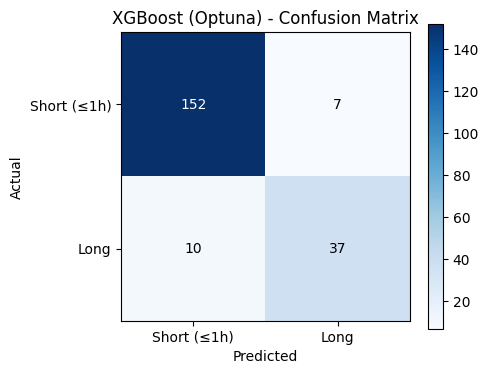

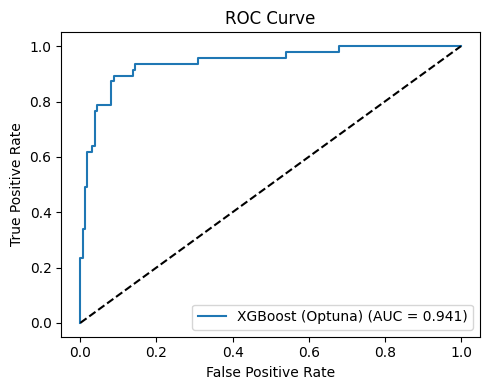

In [172]:
X_cls, y_cls, df_spikes_cls = prepare_classification_dataset(df, threshold_minutes=60)

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = split_data(
    X_cls, y_cls, test_size=0.2, val_size=0.1, random_state=42
)

print("\n=== Logistic Regression ===")
lr_cls, lr_train_pred, lr_train_proba, lr_val_pred, lr_val_proba = train_logistic_regression(
    X_train_c, y_train_c, X_val_c, y_val_c
)
lr_cls_metrics = evaluate_classification(y_val_c, lr_val_pred, lr_val_proba, "Logistic Regression")
lr_coef = report_logistic_coefficients(lr_cls, X_cls.columns.tolist(), X_train_c, y_train_c)

print("\n=== XGBoost Classifier (without Optuna) ===")
xgb_cls, xgb_train_pred, xgb_train_proba, xgb_val_pred, xgb_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=False
)
xgb_metrics = evaluate_classification(y_val_c, xgb_val_pred, xgb_val_proba, "XGBoost Classifier")
xgb_imp = report_xgboost_classifier_importance(xgb_cls, X_cls.columns.tolist())

print("\n=== XGBoost Classifier (with Optuna) ===")
xgb_opt, _, _, xgb_opt_val_pred, xgb_opt_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=True, n_trials=30
)
opt_metrics = evaluate_classification(y_val_c, xgb_opt_val_pred, xgb_opt_val_proba, "XGBoost (Optuna)")

### **Hazard modeling (bins)**

In [132]:
print(list(range(0, 60*24, 30)))

[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]


In [225]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index

# BINS_MINUTES = [0, 30, 120, 360, 1440]
BINS_MINUTES = range(0, 60*24, 30)
BINS_MINUTES = [0, 60, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
BINS_MINUTES = [0, 60, 120, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
BINS_MINUTES = [0, 30, 60, 180, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
# BINS_MINUTES = [0, 180, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]

BIN_LABELS = []
for i in range(len(BINS_MINUTES)-1): BIN_LABELS.append(f"{BINS_MINUTES[i-1]}-{BINS_MINUTES[i]}m")

def prepare_hazard_dataset(df_long, bins=BINS_MINUTES):
    df = df_long.copy()
    df['duration_minutes'] = df['spike_duration_seconds'] / 60.0
    df['bin_start'] = np.nan
    df['bin_end'] = np.nan
    df['bin_label'] = ''
    df['event'] = 0

    rows = []
    for spike_idx, group in df.groupby('spike_index'):
        group = group.sort_values('time_offset_minutes')
        duration = group['duration_minutes'].iloc[0]
        tol = 0
        for i in range(len(bins) - 1):
            bin_start = bins[i]
            bin_end = bins[i + 1]
            mask_bin_start = group['time_offset_minutes'] == bin_start
            if not mask_bin_start.any():
                continue
            row_at_start = group[mask_bin_start].iloc[0]
            event = 1 if (duration > bin_start and duration <= bin_end) else 0
            if tol > 0:
                event = 1
            if i == len(bins) - 2:
                event = 1
            row_at_start = row_at_start.copy()
            row_at_start['bin_start'] = bin_start
            row_at_start['bin_end'] = bin_end
            row_at_start['bin_label'] = f"{bin_start}-{bin_end}m"
            row_at_start['event'] = event
            row_at_start['bin_idx'] = i
            rows.append(row_at_start)
            if event == 1 or duration <= bin_start:
                tol += 1
                if tol >= 3:
                    break

    hazard_df = pd.DataFrame(rows)
    return hazard_df

def train_hazard_model(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def display_hazard_model_coefficients(model, feature_names):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print("Top Features by Absolute Coefficient Magnitude:")
    print(coef_df.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'].head(15), coef_df['Coefficient'].head(15), color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Hazard Model - Top 15 Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df


def evaluate_hazard_model(model, X_val, y_val, hazard_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    brier = brier_score_loss(y_val, y_pred_proba)
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    print(f"Validation AUC: {auc:.4f}")
    print(f"Validation Brier Score: {brier:.4f}")
    print(f"Concordance Index: {c_index:.4f}")

    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask = hazard_val['bin_label'] == bin_label
        if mask.sum() > 0:
            bin_brier[bin_label] = brier_score_loss(y_val[mask], y_pred_proba[mask])
    print("\nBrier Score per bin:")
    for bin_label, score in bin_brier.items():
        print(f"{bin_label}: {score:.4f}")

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'LogReg (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Hazard Model')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred_proba

def plot_calibration(y_true, y_pred_proba, n_bins=10):
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins)
    plt.figure(figsize=(5,4))
    plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
    plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

def predict_survival_curve(model, X_spike_start, bins=BINS_MINUTES):
    bin_starts = bins[:-1]
    pred_probs = []
    X_repeated = pd.DataFrame(np.repeat(X_spike_start.values, len(bin_starts), axis=0), columns=X_spike_start.columns)
    prob_event = model.predict_proba(X_repeated)[:, 1]
    surv = [1.0]
    for i, p in enumerate(prob_event):
        surv.append(surv[-1] * (1 - p))
    return np.array(bins), np.array(surv)

def plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=10, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    
    spike_errors = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_duration = predict_expected_duration(model, X_spike, bins)
        error = abs(true_duration - pred_duration)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_duration,
            'pred_duration': pred_duration,
            'abs_error': error
        })
    
    errors_df = pd.DataFrame(spike_errors)
    
    durations = errors_df['duration_minutes']
    short_threshold = 60 * 1
    long_threshold = 60 * 3
    
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'
    
    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(10, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(10, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(10, 'abs_error')
    
    fig, axes = plt.subplots(3, n_examples_per_row, figsize=(4*n_examples_per_row, 12))
    
    row_labels = ['Short Spikes', 'Medium Spikes', 'Long Spikes']
    spike_groups = [best_short, best_medium, best_long]
    
    for row_idx, (spike_group, label) in enumerate(zip(spike_groups, row_labels)):
        n_sample = min(n_examples_per_row, len(spike_group))
        if n_sample == 0:
            for col_idx in range(n_examples_per_row):
                axes[row_idx, col_idx].set_visible(False)
            continue
            
        sample_spikes = spike_group.sample(n=n_sample, random_state=42)
        
        for col_idx, (_, spike_row) in enumerate(sample_spikes.iterrows()):
            spike_idx = spike_row['spike_index']
            true_duration = spike_row['duration_minutes']
            pred_duration = spike_row['pred_duration']
            error = spike_row['abs_error']
            mask = hazard_val['spike_index'] == spike_idx
            X_spike = X_val.loc[mask].iloc[[0]]
            
            times, surv = predict_survival_curve(model, X_spike, bins)
            
            ax = axes[row_idx, col_idx]
            ax.step(times, surv, where='post', linewidth=2)
            ax.axvline(x=true_duration, color='red', linestyle='--', linewidth=1.5, label=f'True: {true_duration:.0f}m')
            ax.axvline(x=pred_duration, color='blue', linestyle=':', linewidth=1.5, label=f'Pred: {pred_duration:.0f}m')
            ax.set_xlabel('Time (minutes)')
            ax.set_ylabel('Survival probability')
            ax.set_title(f'Spike {spike_idx}')
            ax.legend(loc='lower left', fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)
        
        for col_idx in range(n_sample, n_examples_per_row):
            axes[row_idx, col_idx].set_visible(False)
        
        axes[row_idx, 0].set_ylabel(f'{label}\nSurvival probability')
    
    plt.suptitle('Best Predicted Survival Curves by Duration Category (Top 10 per category)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES, n_bootstrap=100, clip=1440):
    from sklearn.utils import resample
    
    unique_spikes = hazard_val.groupby('spike_index').first().reset_index()
    true_durations = unique_spikes['duration_minutes'].values
    
    pred_durations = []
    for idx, row in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == row['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_durations.append(predict_expected_duration(model, X_spike, bins))
    pred_durations = np.array(pred_durations)
    
    plt.figure(figsize=(6, 6))
    mask = (true_durations < clip) & (pred_durations < clip)
    true_durations = true_durations[mask]
    pred_durations = pred_durations[mask]
    
    plt.scatter(true_durations, pred_durations, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(true_durations.max(), pred_durations.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted expected duration (minutes)')
    plt.title('Actual vs Predicted Expected Duration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    mae = np.mean(np.abs(true_durations - pred_durations))
    print(f"MAE of expected duration: {mae:.2f} minutes")

def predict_expected_duration(model, X_spike, bins=BINS_MINUTES):
    times, surv = predict_survival_curve(model, X_spike, bins)
    expected_duration = 0
    for i in range(len(times) - 1):
        expected_duration += surv[i] * (times[i+1] - times[i])
    return expected_duration


Validation AUC: 0.8444
Validation Brier Score: 0.1522
Concordance Index: 0.8463

Brier Score per bin:
990-1020m: 0.1216
330-360m: 0.1247
900-930m: 0.0003
180-240m: 0.1933
30-60m: 0.2369
750-780m: 0.0019
0-30m: 0.2176
360-390m: 0.0545
510-540m: 0.0888
300-330m: 0.0820
60-180m: 0.2477
930-960m: 0.0004
690-720m: 0.0031
780-810m: 0.0012
240-270m: 0.1563
390-420m: 0.0590
660-690m: 0.0638
540-570m: 0.0775
570-600m: 0.0608
480-510m: 0.0219
600-630m: 0.0571
270-300m: 0.1307
720-750m: 0.0632
810-840m: 0.0797
450-480m: 0.0826
1350-1380m: 0.0000
1290-1320m: 0.0000
630-660m: 0.0055
420-450m: 0.0791
1080-1110m: 0.0001
870-900m: 0.0956
1110-1140m: 0.0000
1260-1290m: 0.1655
1200-1230m: 0.0000
840-870m: 0.0005
1170-1200m: 0.0000
1020-1050m: 0.0001
960-990m: 0.0002
1230-1260m: 0.0000
1140-1170m: 0.0000
1050-1080m: 0.1966
1320-1350m: 0.0000
1380-1410m: 0.9964


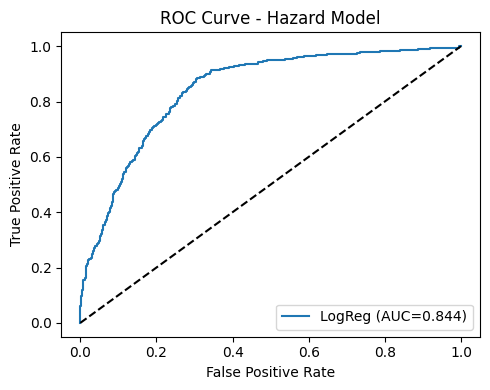

Validation AUC: 0.8069
Validation Brier Score: 0.1660
Concordance Index: 0.8299

Brier Score per bin:
0-30m: 0.2200
180-240m: 0.2003
1170-1200m: 0.0000
450-480m: 0.0772
630-660m: 0.0310
600-630m: 0.0339
30-60m: 0.2395
480-510m: 0.0965
420-450m: 0.0615
570-600m: 0.0541
270-300m: 0.1514
870-900m: 0.0693
60-180m: 0.2460
240-270m: 0.1535
840-870m: 0.1015
660-690m: 0.0175
510-540m: 0.0241
330-360m: 0.1196
300-330m: 0.1310
1080-1110m: 0.0820
750-780m: 0.0375
720-750m: 0.1120
690-720m: 0.0750
390-420m: 0.0963
360-390m: 0.0749
780-810m: 0.0624
1200-1230m: 0.1294
930-960m: 0.0256
540-570m: 0.0514
960-990m: 0.0795
1380-1410m: 0.9967
1110-1140m: 0.0000
1260-1290m: 0.1489
1320-1350m: 0.0524
810-840m: 0.0397
1020-1050m: 0.1090
900-930m: 0.0237
1140-1170m: 0.0000
1350-1380m: 0.0000
990-1020m: 0.0839
1050-1080m: 0.0945
1230-1260m: 0.0472
1290-1320m: 0.0000


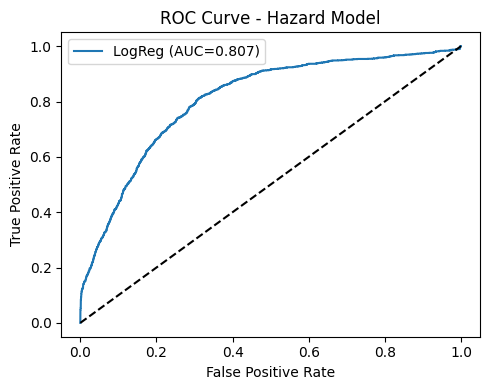

Top Features by Absolute Coefficient Magnitude:
                   Feature  Coefficient
                   bin_idx    -0.149758
        num_spikes_last_7d     0.029521
                top3_share    -0.009968
         utilization_start    -0.007866
       utilization_current    -0.007774
                top1_share    -0.006707
avg_utilization_24h_before    -0.006698
        n_active_borrowers    -0.002752
         borrow_rate_start    -0.001653
       avg_rate_24h_before    -0.001000


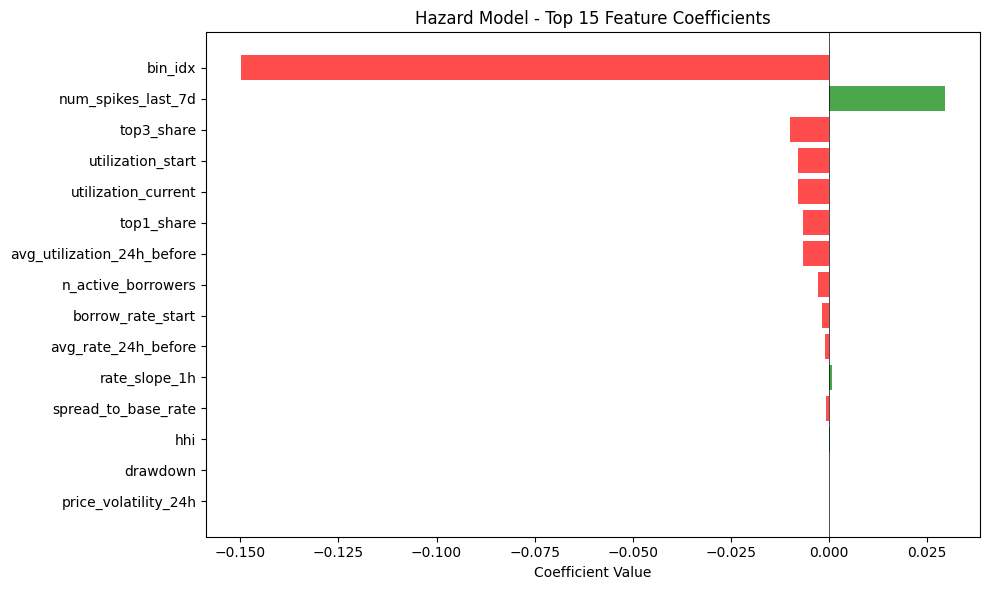

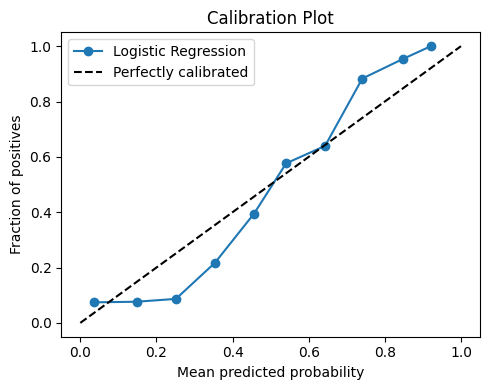

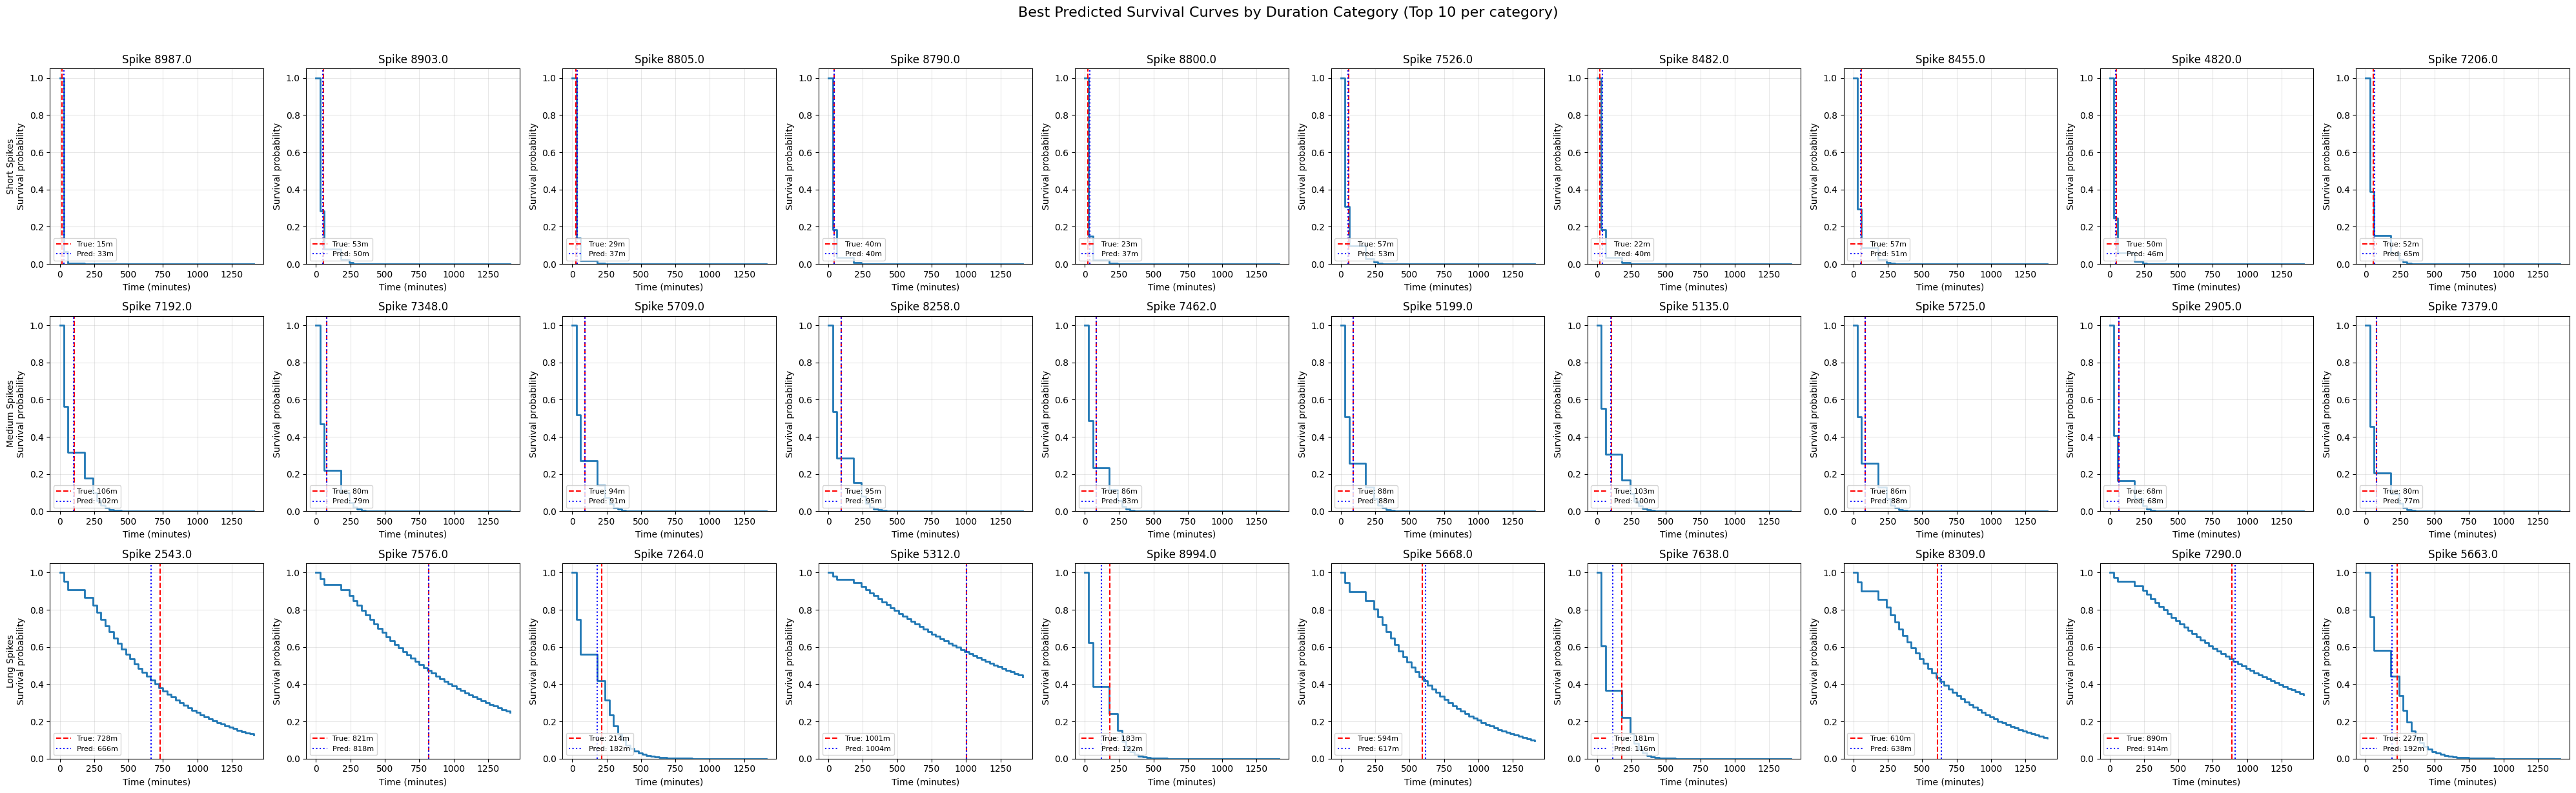

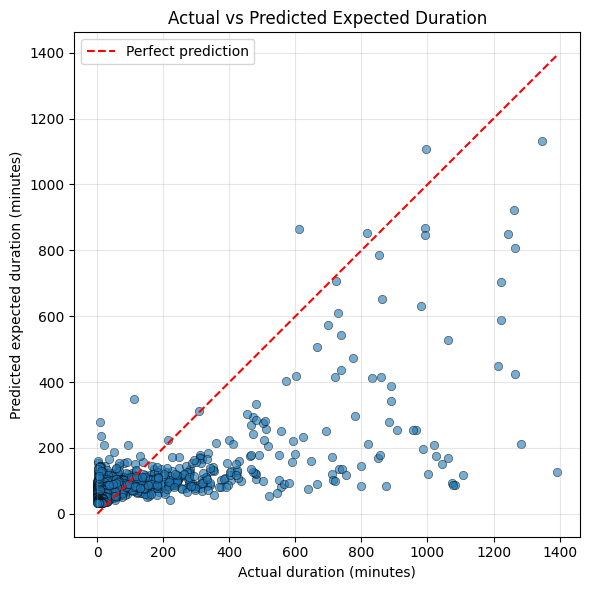

MAE of expected duration: 86.73 minutes


In [227]:
df_prep = df.copy()
# df_prep = df_prep[
#     df_prep["spike_duration_seconds"] > 60*60 * 2
# ]
hazard_df = prepare_hazard_dataset(df_prep, bins=BINS_MINUTES)

feature_cols = [
    'utilization_start', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike',

    'utilization_current',
    # 'time_offset_minutes',
    'bin_idx',
    # 'utilization_peak_so_far',
]
X = hazard_df[feature_cols].fillna(0)
y = hazard_df['event']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
val_idx = X_val.index
hazard_val = hazard_df.loc[val_idx]
hazard_train = hazard_df.loc[X_train.index]

model = train_hazard_model(X_train, y_train)
y_pred_proba = evaluate_hazard_model(model, X_val, y_val, hazard_val)
y_pred_proba_train = evaluate_hazard_model(model, X_train, y_train, hazard_train)

display_hazard_model_coefficients(model, feature_cols)

# plot_calibration(y_val, y_pred_proba)
plot_calibration(y_train, y_pred_proba_train)

plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=10, bins=BINS_MINUTES)
# plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES)
plot_kaplan_meier_style_comparison(model, X_train, hazard_train, bins=BINS_MINUTES)


In [191]:
hazard_df['spike_index'].unique()[:30]

array([2538, 2539, 2540, 2541, 2542, 2543, 2544, 2545, 2546, 2547, 2548,
       2549, 2550, 2551, 2552, 2553, 2554, 2555, 2556, 2557, 2558, 2559,
       2560, 2561, 2562, 2563, 2564, 2565, 2566, 2567])

In [201]:
hazard_df[hazard_df['spike_index'] == 2540]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,duration_minutes,bin_start,bin_end,bin_label,event
11,eth_PT-reUSD-25JUN2026_usdc,2540,0.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,0.000000,0.001962,0.000787,0.915225,0.099344,2,109716.0,10104.0,10104,1.766019e+09,1.766019e+09,168.4,0,30,0-30m,0
12,eth_PT-reUSD-25JUN2026_usdc,2540,30.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,8304.0,10104,1.766021e+09,1.766019e+09,168.4,30,60,30-60m,0
13,eth_PT-reUSD-25JUN2026_usdc,2540,60.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,6504.0,10104,1.766023e+09,1.766019e+09,168.4,60,180,60-180m,1


In [216]:
spikes_util_diffs = {}
fields_list = ['utilization_current', 'hhi', 'top3_share', 'top1_share', 'total_borrow_current']
for f in fields_list: spikes_util_diffs[f] = []
for i in hazard_df['spike_index'].unique():
    for field in fields_list:
        # print(hazard_df[hazard_df['spike_index'] == i].shape)
        lst = list(hazard_df[hazard_df['spike_index'] == i][field])[0]
        data = list(hazard_df[(hazard_df['spike_index'] == i) & (hazard_df['event'] == 0)][field] - lst)[1:]
        if len(data) == 0:
            continue
        spikes_util_diffs[field].append(np.mean(data))
        # print(spikes_util_diffs)


utilization_current
count    499.000000
mean      -0.011021
std        0.023022
min       -0.096623
25%       -0.015047
50%        0.000000
75%        0.000000
max        0.033820
dtype: float64


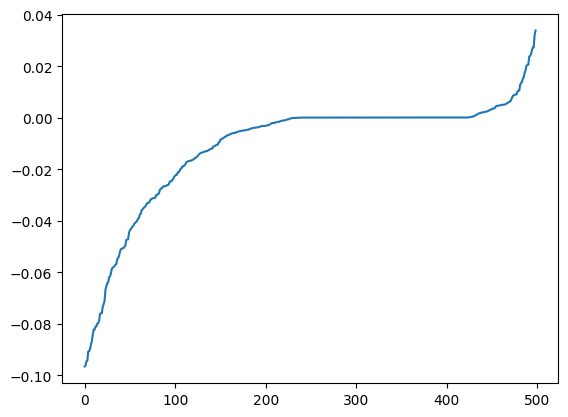

hhi
count    499.000000
mean       0.000136
std        0.008215
min       -0.098738
25%        0.000000
50%        0.000000
75%        0.000000
max        0.098670
dtype: float64


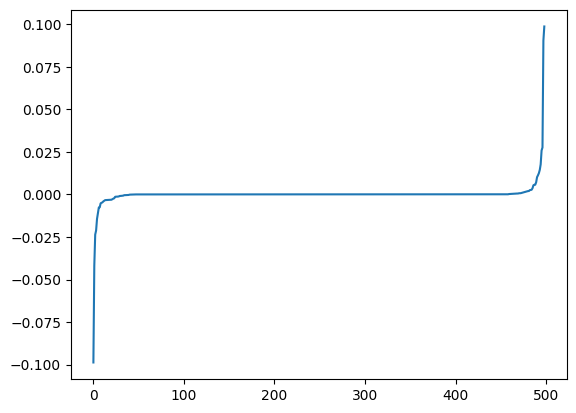

top3_share
count    499.000000
mean      -0.000407
std        0.007110
min       -0.114044
25%        0.000000
50%        0.000000
75%        0.000000
max        0.028968
dtype: float64


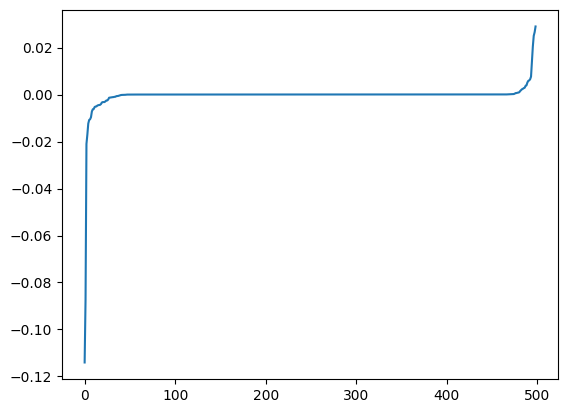

top1_share
count    499.000000
mean      -0.000056
std        0.011598
min       -0.164109
25%        0.000000
50%        0.000000
75%        0.000000
max        0.116392
dtype: float64


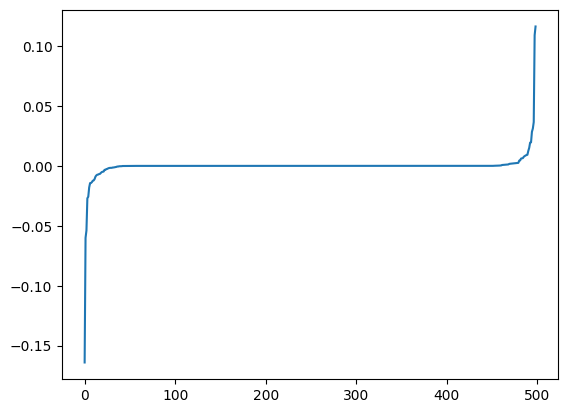

total_borrow_current
count    4.990000e+02
mean    -1.908458e+04
std      2.960393e+05
min     -2.831152e+06
25%      0.000000e+00
50%      7.108359e+00
75%      1.196789e+02
max      2.836898e+06
dtype: float64


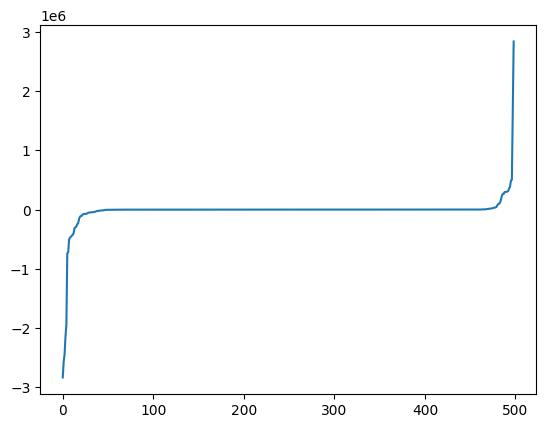

In [217]:
for f in fields_list:
    print(f)
    print(pd.Series(spikes_util_diffs[f]).describe())
    pd.Series(sorted(spikes_util_diffs[f])).plot()
    plt.show()
